<a href="https://colab.research.google.com/github/Hirakhan15/PCOs/blob/main/resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

ROOT_DIR = '/content/drive/MyDrive/PCOS'
number_of_images = {}

for dir in os.listdir(ROOT_DIR):
   number_of_images[dir] = len(os.listdir(os.path.join(ROOT_DIR,dir)))
   print("",dir,"" ,number_of_images[dir])

 noninfected  5000
 infected  5000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = []
for category in ['infected', 'noninfected']:
    folder_path = os.path.join(ROOT_DIR, category)
    for img in os.listdir(folder_path):
        data.append({'filepath': os.path.join(folder_path, img), 'label': category})

df = pd.DataFrame(data)

# Splitting 70/15/15
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # This now uses ResNet logic
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only Preprocessing for Val/Test
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_gen = test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

Found 7000 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Load ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep the base frozen for Transfer Learning

# The rest of your 'head' can stay the same
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('pcos_resnet50.keras', save_best_only=True)
]

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, # Adjusted based on typical PCOS convergence
    callbacks=callbacks
)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 1212s 5s/step - accuracy: 0.8836 - loss: 0.2663 - val_accuracy: 0.9660 - val_loss: 0.0983
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 637ms/step - accuracy: 0.9507 - loss: 0.1264 - val_accuracy: 0.9647 - val_loss: 0.0925
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 138s 626ms/step - accuracy: 0.9614 - loss: 0.1009 - val_accuracy: 0.9313 - val_loss: 0.1276
Epoch 4/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 133s 608ms/step - accuracy: 0.9701 - loss: 0.0837 - val_accuracy: 0.9507 - val_loss: 0.1011
Epoch 5/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 136s 622ms/step - accuracy: 0.9757 - loss: 0.0620 - val_accuracy: 0.9547 - val_loss: 0.0896
Epoch 6/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 136s 621ms/step - accuracy: 0.9774 - loss: 0.0654 - val_accuracy: 0.9493 - val_loss: 0.1055
Epoch 7/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 634ms/step - accuracy: 0.9826 - loss: 0.0553 - val_accuracy: 0.9567 - val_loss: 0.0949
Epoch 8/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 634ms/step - accuracy: 0.9834 - l

In [ ]:
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

loss, accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

Found 1500 validated image filenames belonging to 2 classes.
47/47 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9693 - loss: 0.0799
Final Test Accuracy: 96.93%


47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 299ms/step


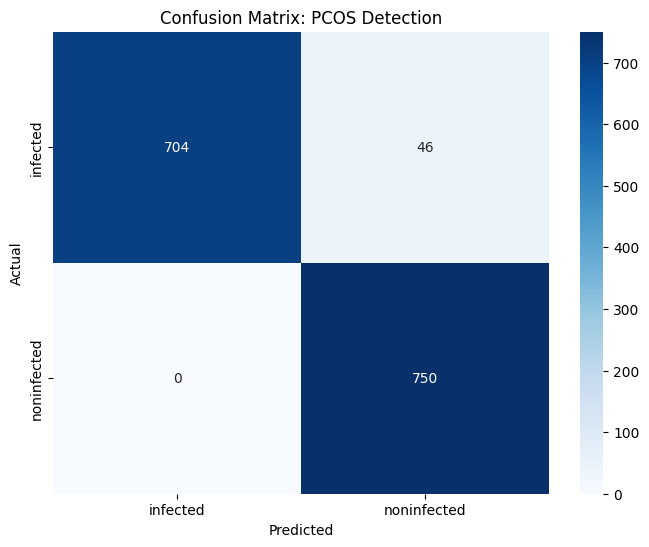


Classification Report:
              precision    recall  f1-score   support

    infected       1.00      0.94      0.97       750
 noninfected       0.94      1.00      0.97       750

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
# Important: shuffle=False in test_gen ensures labels match predictions
test_gen.reset()
predictions = model.predict(test_gen)
pred_labels = (predictions > 0.5).astype(int) # Convert probabilities to 0 or 1

# 2. Get true labels
true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 3. Create Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: PCOS Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 4. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

In [ ]:
# Assuming 'cm' is your confusion matrix from the previous step
# In a binary classification (0=Healthy, 1=Infected):
# cm[0,0] = TN, cm[0,1] = FP
# cm[1,0] = FN, cm[1,1] = TP

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Healthy correctly identified): {tn}")
print(f"False Positives (Healthy misidentified as PCOS): {fp}")
print(f"False Negatives (PCOS missed by model): {fn}")
print(f"True Positives (PCOS correctly identified): {tp}")

True Negatives (Healthy correctly identified): 704
False Positives (Healthy misidentified as PCOS): 46
False Negatives (PCOS missed by model): 0
True Positives (PCOS correctly identified): 750


In [ ]:
model.save("pcos_resnet50.keras")

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("pcos_resnet50.tflite", "wb") as f:
    f.write(tflite_model)

from google.colab import files
files.download("pcos_resnet50.tflite")

Saved artifact at '/tmp/tmphl0cqh1_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132109656367632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656368400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656367824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656368976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656366672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656365328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656370320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656371664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656373584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132109656373776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13210965637300

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>